# Install lib


In [2]:
!pip install pandas matplotlib numpy seaborn 


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: C:\Users\fabot\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


# import lib / data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/processed/enriched_data.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   transaction_id              120000 non-null  object 
 1   transaction_date            120000 non-null  object 
 2   customer_id                 120000 non-null  object 
 3   customer_gender             120000 non-null  object 
 4   customer_age_group          120000 non-null  object 
 5   customer_segment            120000 non-null  object 
 6   product_id                  120000 non-null  object 
 7   product_name                120000 non-null  object 
 8   category                    120000 non-null  object 
 9   brand                       120000 non-null  object 
 10  quantity                    120000 non-null  float64
 11  unit_price                  120000 non-null  float64
 12  discount_pct                120000 non-null  int64  
 13  sales_amount  

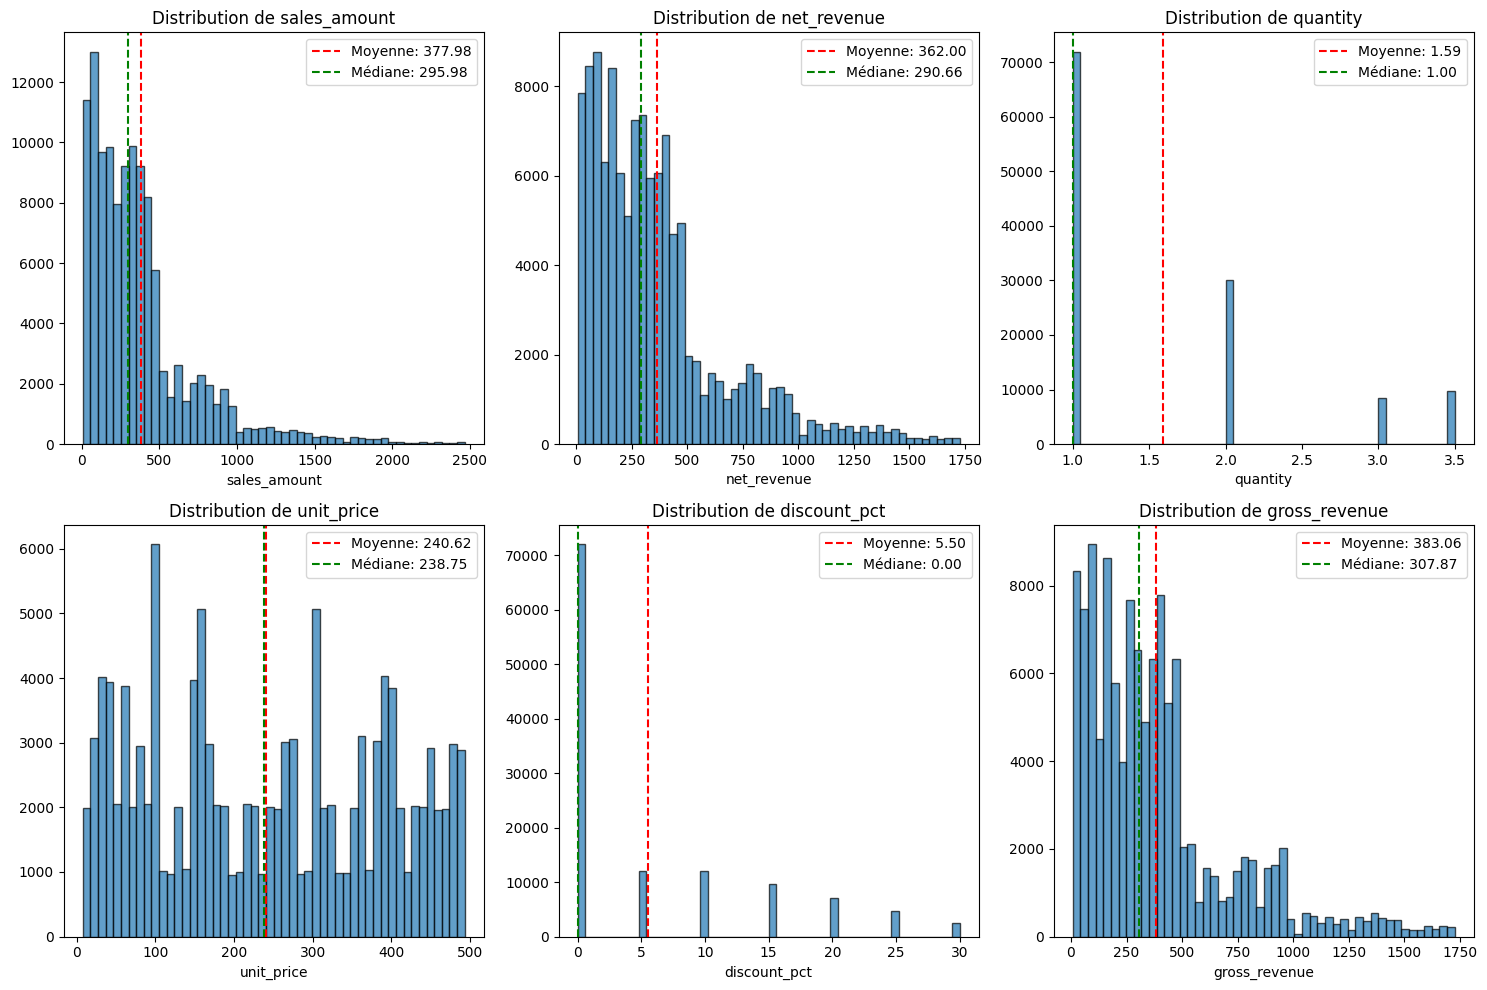

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numerical_cols = ['sales_amount', 'net_revenue', 'quantity', 'unit_price', 'discount_pct', 'gross_revenue']
for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    
    axes[row, col_idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[row, col_idx].axvline(mean_val, color='red', linestyle='--', label=f'Moyenne: {mean_val:.2f}')
    axes[row, col_idx].axvline(median_val, color='green', linestyle='--', label=f'Médiane: {median_val:.2f}')
    
    axes[row, col_idx].set_title(f'Distribution de {col}')
    axes[row, col_idx].legend()
    axes[row, col_idx].set_xlabel(col)

plt.tight_layout()
plt.show()

Colonnes catégorielles : ['transaction_id', 'transaction_date', 'customer_id', 'customer_gender', 'customer_age_group', 'customer_segment', 'product_id', 'product_name', 'category', 'brand', 'payment_method', 'sales_channel', 'region', 'day_of_week']


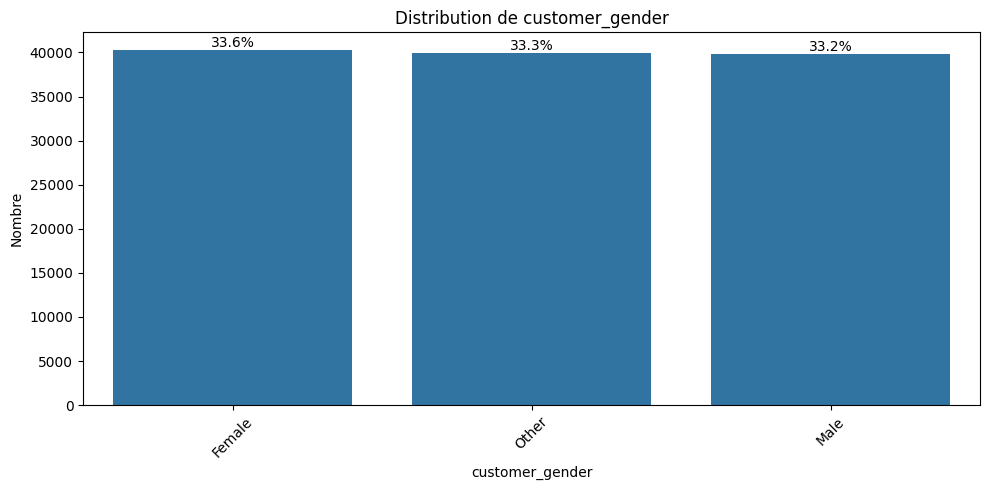

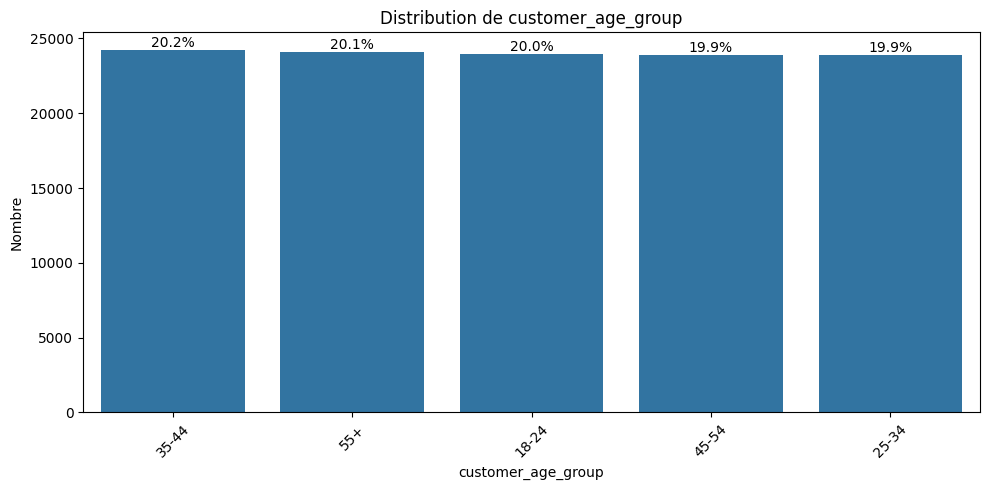

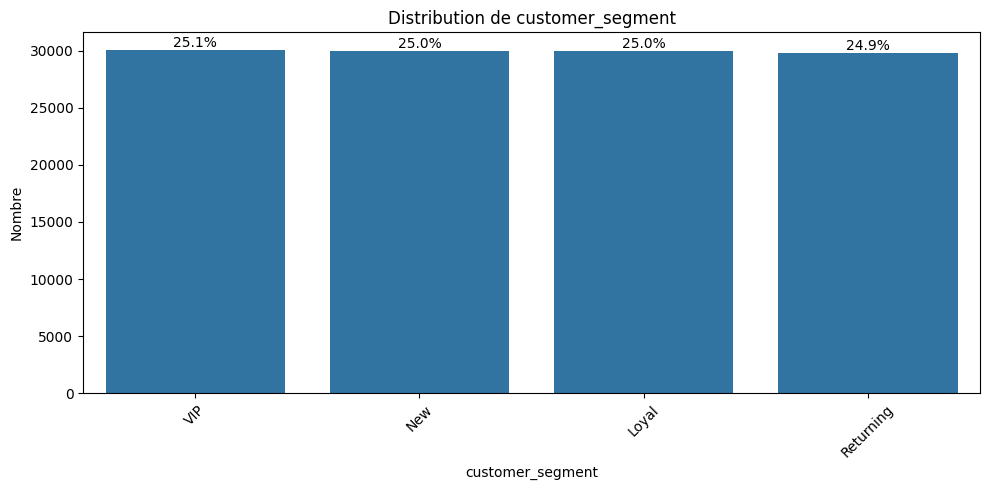

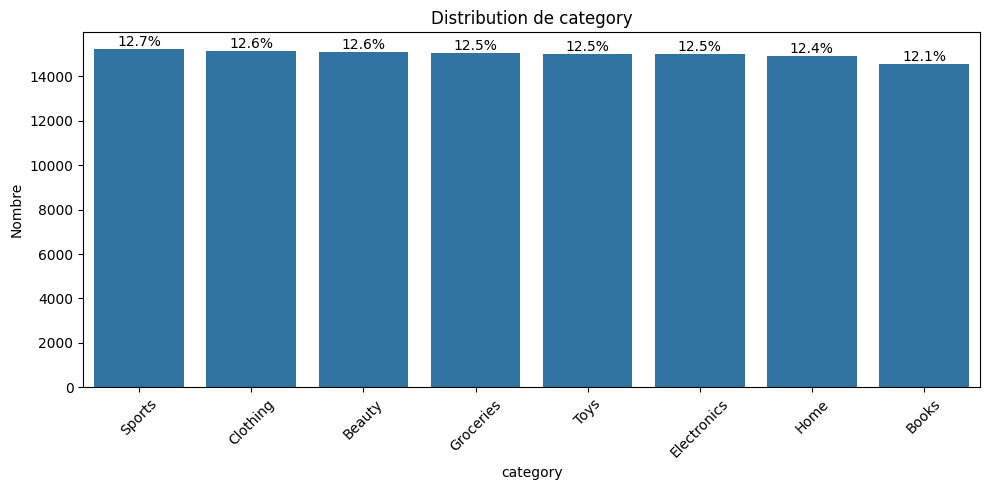

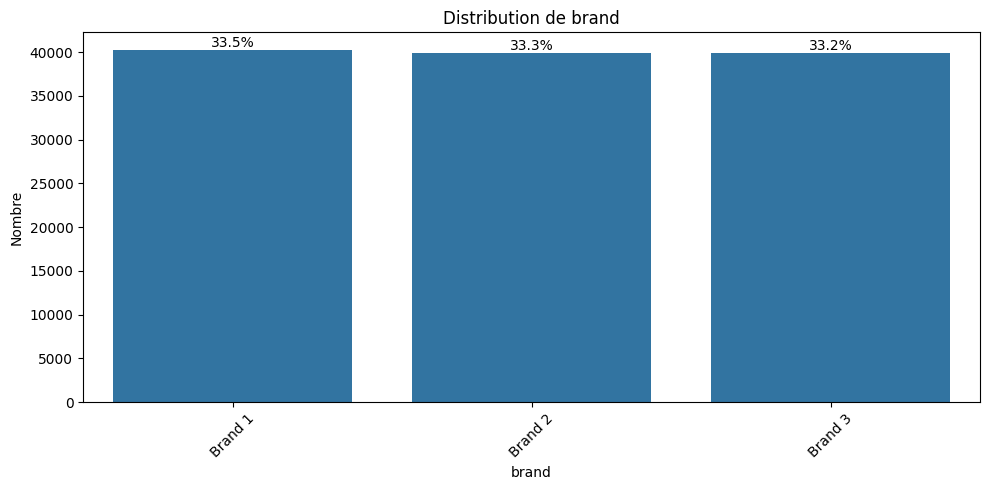

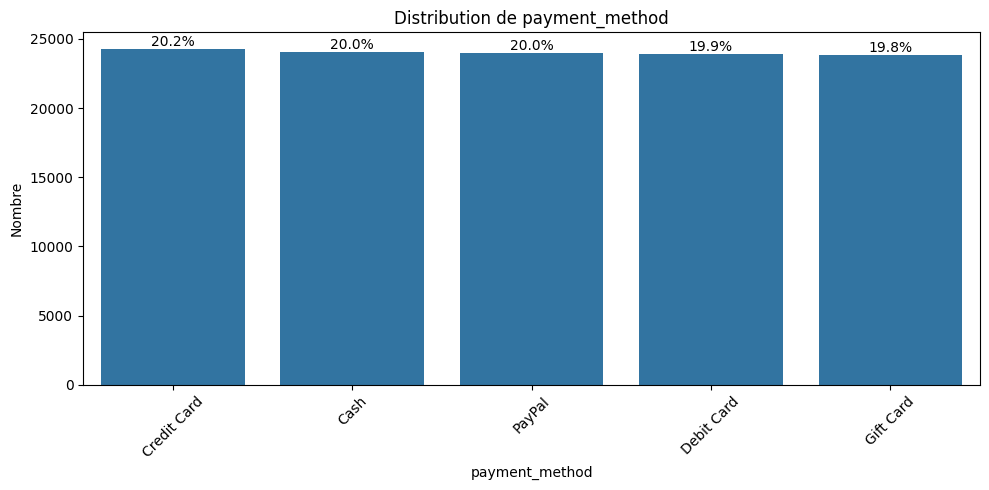

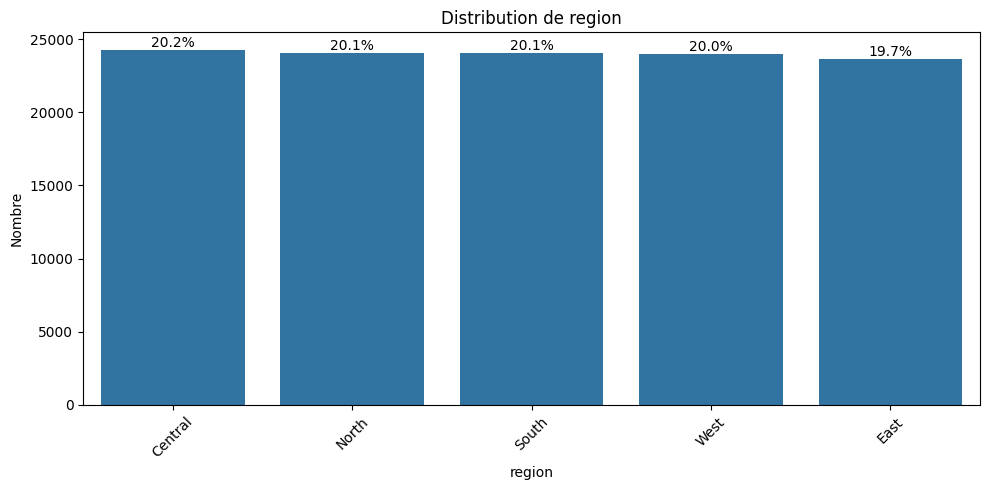

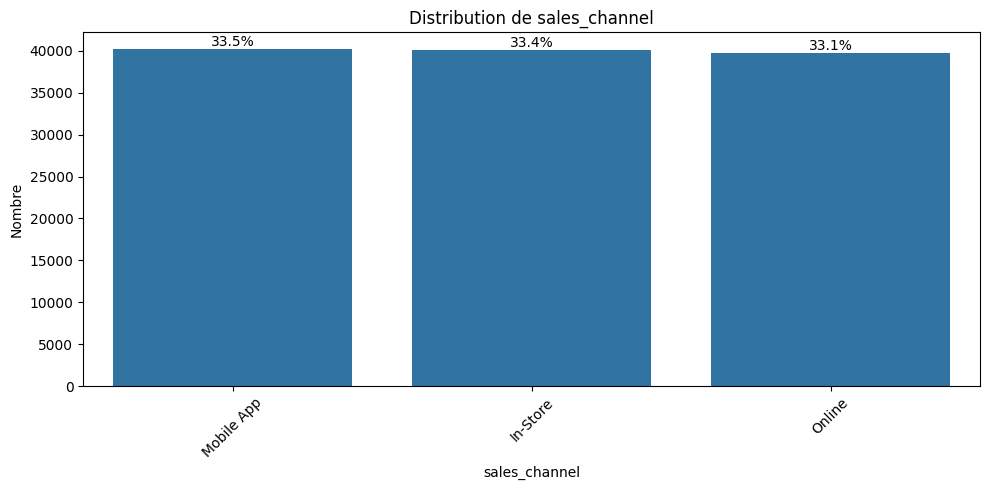

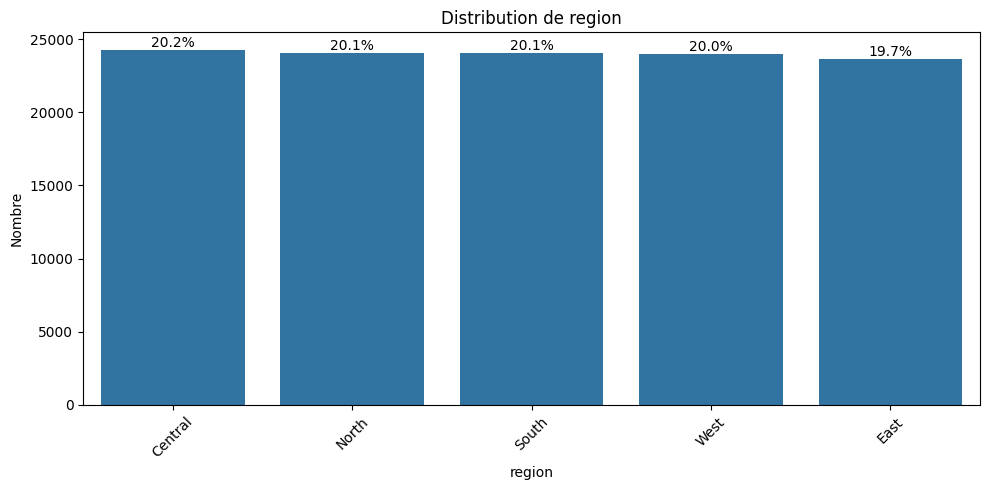

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Colonnes catégorielles : {categorical_cols}")

categorical_cols = ["customer_gender","customer_age_group","customer_segment","category", "brand", "payment_method", "region","sales_channel","region"]

for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.countplot(data=df, x=col, ax=ax, 
                 order=df[col].value_counts().index)
    
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage, 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom')
    
    ax.set_title(f'Distribution de {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Nombre')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


📊 ANALYSE DES SEGMENTS CLIENTS
                     CA_total  CA_moyen  nb_transactions  nb_clients  \
customer_segment                                                       
Loyal             10906615.93    363.38            30014       17336   
New               10851631.53    361.48            30020       17524   
Returning         10830787.52    362.83            29851       17435   
VIP               10851062.42    360.32            30115       17535   

                  CA_par_client  
customer_segment                 
Loyal                    629.13  
New                      619.24  
Returning                621.21  
VIP                      618.82  


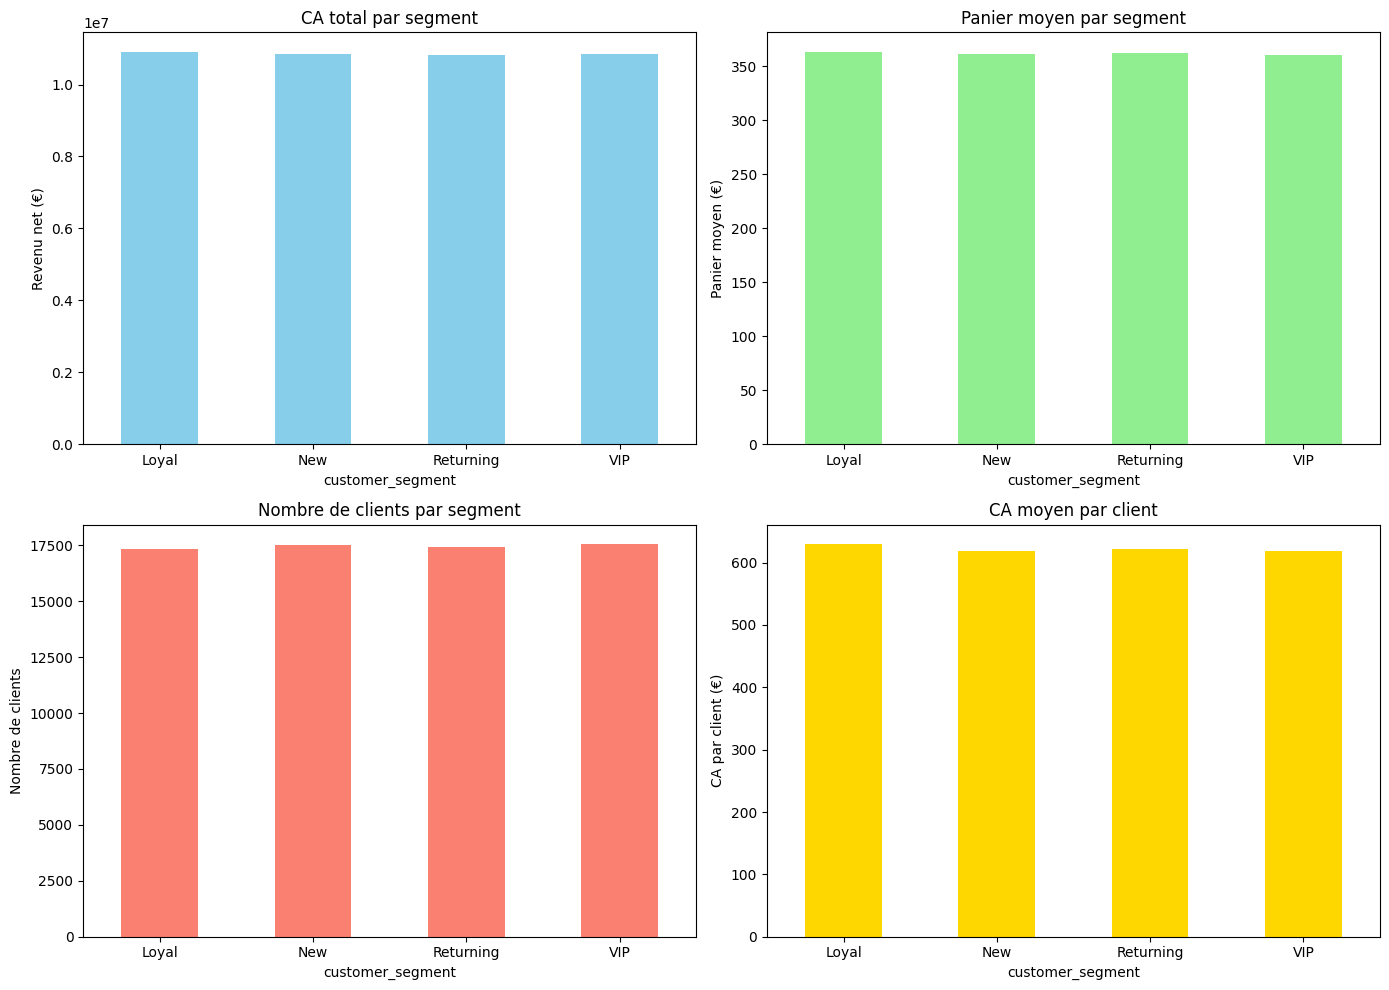

In [ ]:
segment_stats = df.groupby('customer_segment').agg({
    'net_revenue': ['sum', 'mean', 'count'],
    'customer_id': 'nunique'
}).round(2)

segment_stats.columns = ['CA_total', 'CA_moyen', 'nb_transactions', 'nb_clients']
segment_stats['CA_par_client'] = (segment_stats['CA_total'] / segment_stats['nb_clients']).round(2)

print(segment_stats)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

segment_stats['CA_total'].plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('CA total par segment')
axes[0, 0].set_ylabel('Revenu net (€)')
axes[0, 0].tick_params(axis='x', rotation=0)


segment_stats['CA_moyen'].plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Panier moyen par segment')
axes[0, 1].set_ylabel('Panier moyen (€)')
axes[0, 1].tick_params(axis='x', rotation=0)

segment_stats['nb_clients'].plot(kind='bar', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Nombre de clients par segment')
axes[1, 0].set_ylabel('Nombre de clients')
axes[1, 0].tick_params(axis='x', rotation=0)

segment_stats['CA_par_client'].plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('CA moyen par client')
axes[1, 1].set_ylabel('CA par client (€)')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

          CA_total  CA_moyen  nb_transactions   mois_nom
months                                                  
1       3747548.36    366.83            10216    Janvier
2       3441340.34    364.78             9434    Février
3       3552404.71    351.62            10103       Mars
4       3571319.54    361.91             9868      Avril
5       3714344.74    362.38            10250        Mai
6       3571955.02    359.39             9939       Juin
7       3735347.50    365.42            10222    Juillet
8       3735869.12    367.13            10176       Août
9       3538538.22    359.53             9842  Septembre
10      3612451.59    360.42            10023    Octobre
11      3587622.22    363.63             9866   Novembre
12      3631356.04    360.93            10061   Décembre


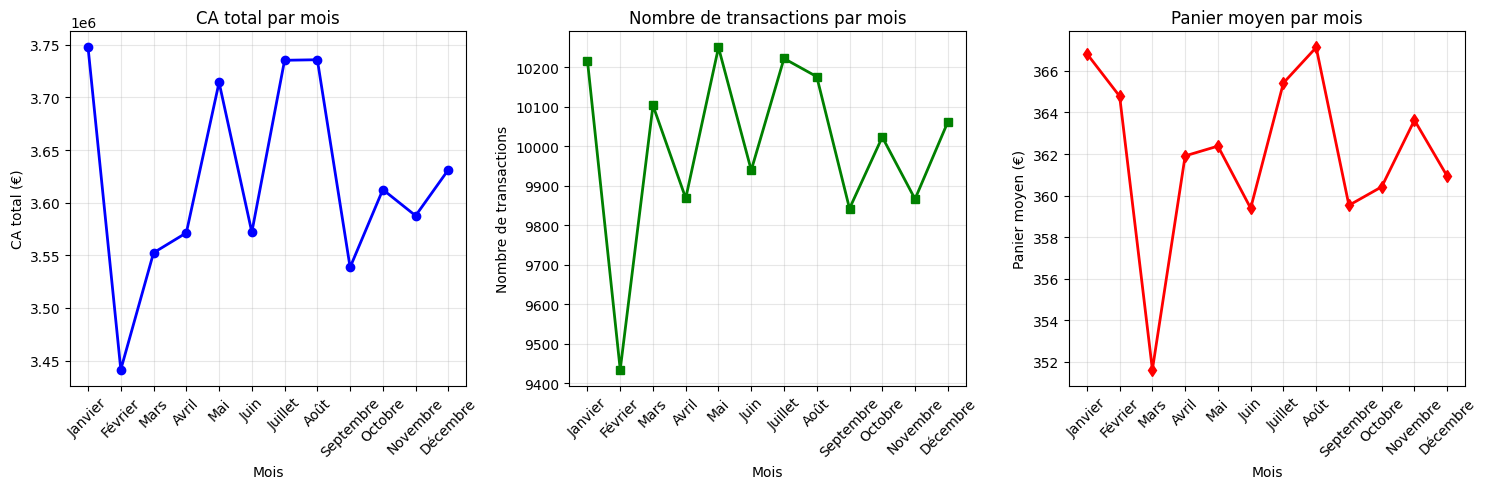

In [ ]:
monthly_sales = df.groupby('months').agg({
    'net_revenue': ['sum', 'mean', 'count']
}).round(2)
monthly_sales.columns = ['CA_total', 'CA_moyen', 'nb_transactions']

month_mapping = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril',
    5: 'Mai', 6: 'Juin', 7: 'Juillet', 8: 'Août',
    9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
}

monthly_sales['mois_nom'] = monthly_sales.index.map(month_mapping)

print(monthly_sales)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(monthly_sales.index, monthly_sales['CA_total'], 
             marker='o', color='blue', linewidth=2)

axes[0].set_xticks(monthly_sales.index)
axes[0].set_xticklabels(monthly_sales['mois_nom'], rotation=45)
axes[0].set_title('CA total par mois')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('CA total (€)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly_sales.index, monthly_sales['nb_transactions'], 
             marker='s', color='green', linewidth=2)
axes[1].set_xticks(monthly_sales.index)
axes[1].set_xticklabels(monthly_sales['mois_nom'], rotation=45)
axes[1].set_title('Nombre de transactions par mois')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre de transactions')
axes[1].grid(True, alpha=0.3)

axes[2].plot(monthly_sales.index, monthly_sales['CA_moyen'], 
             marker='d', color='red', linewidth=2)
axes[2].set_xticks(monthly_sales.index)
axes[2].set_xticklabels(monthly_sales['mois_nom'], rotation=45)
axes[2].set_title('Panier moyen par mois')
axes[2].set_xlabel('Mois')
axes[2].set_ylabel('Panier moyen (€)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
print("client insights")
segment_revenue = df.groupby('customer_segment')['net_revenue'].sum().sort_values(ascending=False)
segment_pct = (segment_revenue / df['net_revenue'].sum() * 100).round(1)

for segment, pct in segment_pct.items():
    print(f"   - {segment}: {pct:.1f}% du CA total")

top_segment = segment_revenue.index[0]
print(f"\nSegment le plus rentable : {top_segment} ({segment_pct[0]:.1f}% du CA)")

# 2. PRODUITS
print("PRODUITS :")
top_product = df.groupby('product_name')['net_revenue'].sum().sort_values(ascending=False).head(5)
print("   Top 5 produits :")

for i, (product, revenue) in enumerate(top_product.items(), 1):
    print(f"   {i}. {product} : {revenue:,.0f}€")

# 3. TEMPOREL
print("TEMPOREL :")
monthly_total = df.groupby('months')['net_revenue'].sum()
best_month = monthly_total.idxmax()
worst_month = monthly_total.idxmin()
best_value = monthly_total.max()
worst_value = monthly_total.min()

month_names = {1:'Janvier',2:'Février',3:'Mars',4:'Avril',5:'Mai',6:'Juin',
               7:'Juillet',8:'Août',9:'Septembre',10:'Octobre',11:'Novembre',12:'Décembre'}

print(f"   - Meilleur mois : {month_names[best_month]} ({best_value:,.0f}€)")
print(f"   - Mois le plus faible : {month_names[worst_month]} ({worst_value:,.0f}€)")
print(f"   - Différence : {(best_value - worst_value):,.0f}€")

# 4. GÉOGRAPHIE
print("GÉOGRAPHIE :")
region_revenue = df.groupby('region')['net_revenue'].sum().sort_values(ascending=False)
for region, revenue in region_revenue.items():
    pct = (revenue / df['net_revenue'].sum() * 100).round(1)
    print(f"   - {region}: {pct:.1f}% du CA")

# 5. CANAUX
print("CANAUX DE VENTE :")
channel_revenue = df.groupby('sales_channel')['net_revenue'].sum().sort_values(ascending=False)
for channel, revenue in channel_revenue.items():
    pct = (revenue / df['net_revenue'].sum() * 100).round(1)
    print(f"   - {channel}: {pct:.1f}% du CA")

#RÉDUCTIONS
print("\n🔹 IMPACT DES RÉDUCTIONS :")
avg_with = df[df['discount']==True]['net_revenue'].mean()
avg_without = df[df['discount']==False]['net_revenue'].mean()
count_with = len(df[df['discount']==True])
count_without = len(df[df['discount']==False])

print(f"   - Transactions avec réduction : {count_with:,} ({count_with/len(df)*100:.1f}%)")
print(f"   - Transactions sans réduction : {count_without:,} ({count_without/len(df)*100:.1f}%)")
print(f"   - Panier moyen avec réduction : {avg_with:.2f}€")
print(f"   - Panier moyen sans réduction : {avg_without:.2f}€")
print(f"   - Différence : {(avg_without - avg_with):.2f}€")

client insights
   - Loyal: 25.1% du CA total
   - New: 25.0% du CA total
   - VIP: 25.0% du CA total
   - Returning: 24.9% du CA total

Segment le plus rentable : Loyal (25.1% du CA)
PRODUITS :
   Top 5 produits :
   1. Bread : 1,988,206€
   2. Lipstick : 1,973,647€
   3. Textbook : 1,668,562€
   4. Smartphone : 1,563,223€
   5. Water Bottle : 1,530,713€
TEMPOREL :
   - Meilleur mois : Janvier (3,747,548€)
   - Mois le plus faible : Février (3,441,340€)
   - Différence : 306,208€
GÉOGRAPHIE :
   - Central: 20.4% du CA
   - West: 20.1% du CA
   - North: 20.0% du CA
   - South: 19.9% du CA
   - East: 19.8% du CA
CANAUX DE VENTE :
   - In-Store: 33.7% du CA
   - Mobile App: 33.2% du CA
   - Online: 33.1% du CA

🔹 IMPACT DES RÉDUCTIONS :
   - Transactions avec réduction : 48,044 (40.0%)
   - Transactions sans réduction : 71,956 (60.0%)
   - Panier moyen avec réduction : 331.25€
   - Panier moyen sans réduction : 382.53€
   - Différence : 51.27€


C:\Users\fabot\AppData\Local\Temp\ipykernel_25972\2644470662.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\nSegment le plus rentable : {top_segment} ({segment_pct[0]:.1f}% du CA)")


TypeError: unhashable type: 'Index'

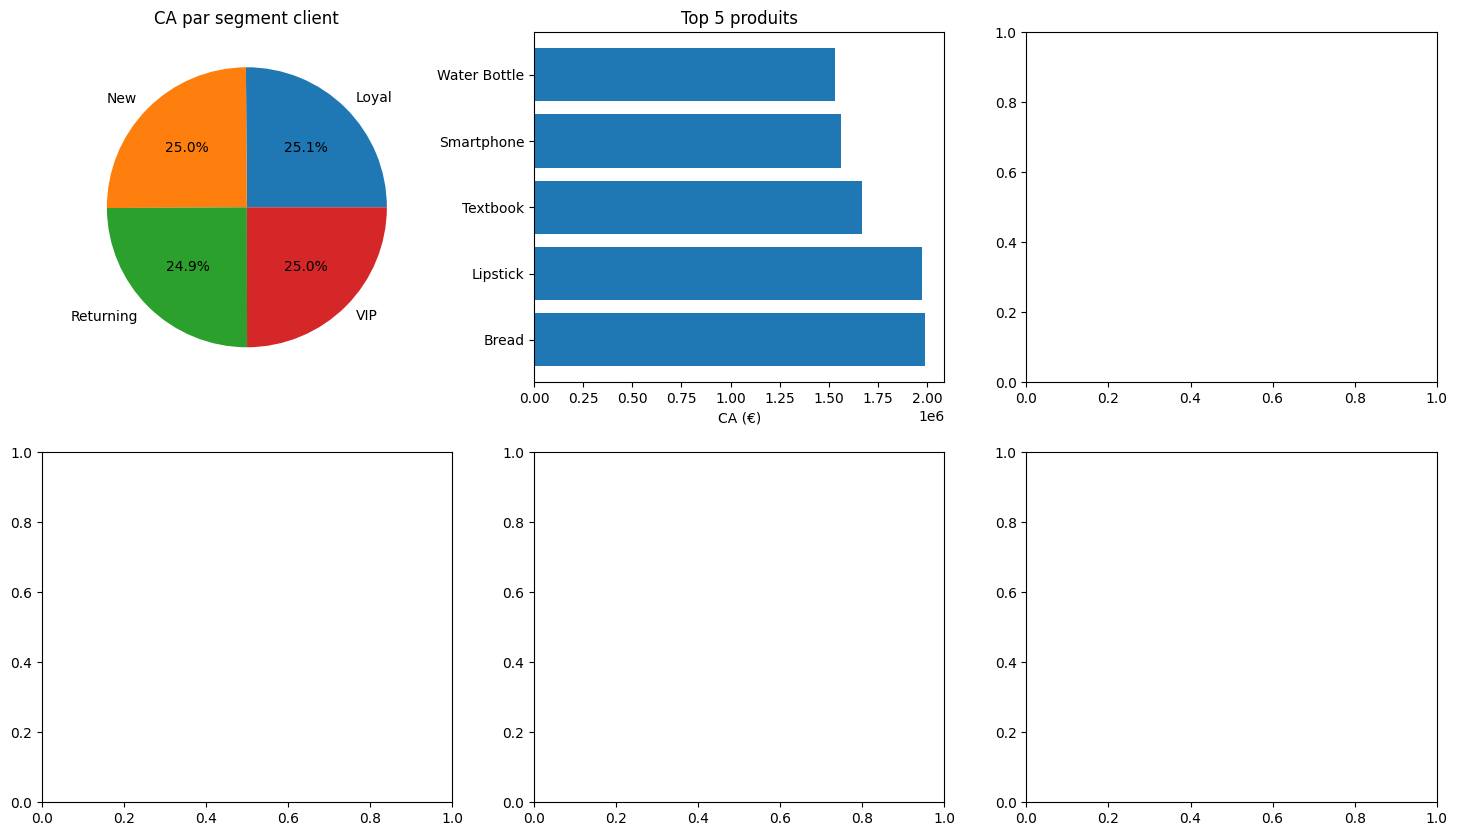

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. CA par segment
segments = df.groupby('customer_segment')['net_revenue'].sum()
axes[0, 0].pie(segments, labels=segments.index, autopct='%1.1f%%')
axes[0, 0].set_title('CA par segment client')

# 2. Top 5 produits
top_products = df.groupby('product_name')['net_revenue'].sum().sort_values(ascending=False).head(5)
axes[0, 1].barh(top_products.index, top_products.values)
axes[0, 1].set_title('Top 5 produits')
axes[0, 1].set_xlabel('CA (€)')

# 3. Ventes par mois
month_names = {1:'Janvier',2:'Février',3:'Mars',4:'Avril',5:'Mai',6:'Juin',
               7:'Juillet',8:'Août',9:'Septembre',10:'Octobre',11:'Novembre',12:'Décembre'}

monthly = df.groupby('months')['net_revenue'].sum()

months_list = [month_names[m] for m in monthly.index]

axes[0, 2].plot(months_list, monthly.values, marker='o', linewidth=2)
axes[0, 2].set_title('Tendance mensuelle')
axes[0, 2].set_xlabel('Mois')
axes[0, 2].set_ylabel('CA (€)')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. CA par région
regions = df.groupby('region')['net_revenue'].sum()
axes[1, 0].bar(regions.index, regions.values)
axes[1, 0].set_title('CA par région')
axes[1, 0].set_xlabel('Région')
axes[1, 0].set_ylabel('CA (€)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. CA par canal
channels = df.groupby('sales_channel')['net_revenue'].sum()
axes[1, 1].bar(channels.index, channels.values)
axes[1, 1].set_title('CA par canal')
axes[1, 1].set_xlabel('Canal')
axes[1, 1].set_ylabel('CA (€)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Impact des réductions
discount_impact = df.groupby('discount')['net_revenue'].mean()
axes[1, 2].bar(['Sans réduction', 'Avec réduction'], discount_impact.values)
axes[1, 2].set_title('Panier moyen avec/sans réduction')
axes[1, 2].set_ylabel('Panier moyen (€)')

plt.tight_layout()
plt.show()